# MLP Activation Functions: Predicting Robertson's Ic from CPT

**Goal**: Compare ReLU vs Tanh for predicting a **bounded** physical quantity.

Robertson's Soil Behavior Type Index:
$$I_c = \sqrt{(3.47 - \log_{10} Q_{tn})^2 + (\log_{10} F_r + 1.22)^2}$$

- **Physical bound**: $I_c \in [0.5, 4.5]$
- **ReLU**: Unbounded $[0, \infty)$
- **Tanh**: Bounded $[-1, 1]$

**Hypothesis**: Tanh should outperform ReLU for bounded quantities.

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Load CPT Data

In [2]:
with open('../03-clustering/all_cpt_profiles.pkl', 'rb') as f:
    cpt_data = pickle.load(f)

all_data = []
for key, profile in cpt_data.items():
    df = profile['data'][['depth', 'qc', 'fs', 'u2', 'Ic', 'Qtn', 'Fr']].copy()
    df = df[(df['Ic'].notna()) & (df['Ic'] > 0)]
    all_data.append(df)

df = pd.concat(all_data, ignore_index=True)
print(f"Loaded {len(df):,} CPT measurements from {len(cpt_data)} profiles")
df.describe()

Loaded 11,177 CPT measurements from 64 profiles


,depth,qc,fs,u2,Ic,Qtn,Fr
count,11177.000000,11177.000000,11177.000000,11177.000000,11177.000000,11177.000000,11177.000000
mean,7.911946,7.055017,0.029867,-0.000206,2.293692,85.077785,1.932241
std,5.074823,8.758263,0.860582,0.041442,0.716373,109.548564,2.359976
min,0.040000,-0.200000,-32.000000,-0.132453,0.613663,1.000000,0.100000
25%,3.700000,1.079100,0.014050,0.000000,1.692664,12.957104,0.433992
50%,7.300000,3.594000,0.032500,0.000000,2.217401,44.975234,1.020963
75%,11.550000,9.871000,0.072374,0.000000,2.913184,121.744010,2.413405
max,22.680000,64.097300,2.534280,0.641097,4.115976,1000.000000,10.000000


## Robertson's Chart

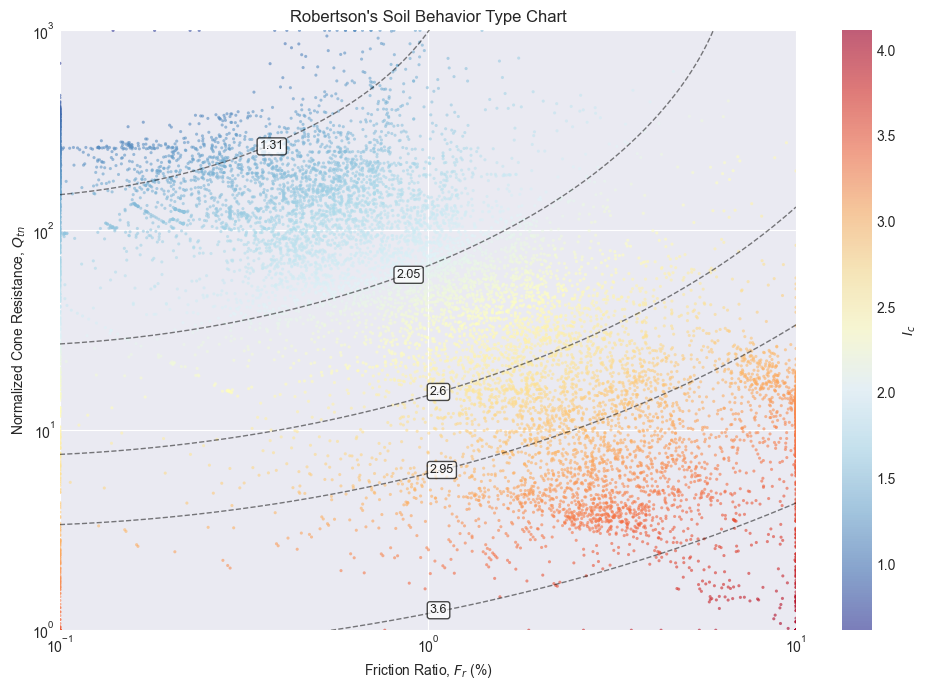

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df['Fr'], df['Qtn'], c=df['Ic'], cmap='RdYlBu_r', 
                     alpha=0.6, s=5, edgecolors='none')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.1, 10); ax.set_ylim(1, 1000)

# Add Ic contours
Fr_range = np.logspace(np.log10(0.1), np.log10(10), 200)
for Ic_val in [1.31, 2.05, 2.60, 2.95, 3.60]:
    log_Fr = np.log10(Fr_range)
    discriminant = Ic_val**2 - (log_Fr + 1.22)**2
    valid = discriminant > 0
    log_Qtn = 3.47 - np.sqrt(discriminant[valid])
    ax.plot(Fr_range[valid], 10**log_Qtn, 'k--', lw=1, alpha=0.5)
    if valid.sum() > 0:
        mid = len(log_Qtn)//2
        ax.text(Fr_range[valid][mid], 10**log_Qtn[mid], f'{Ic_val}', 
                fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

plt.colorbar(scatter, label='$I_c$')
ax.set_xlabel('Friction Ratio, $F_r$ (%)')
ax.set_ylabel('Normalized Cone Resistance, $Q_{tn}$')
ax.set_title("Robertson's Soil Behavior Type Chart");
plt.tight_layout();

## Prepare Dataset

**Task**: Predict $I_c$ from raw measurements: `[qc, fs, u2, depth]`

In [4]:
X = df[['qc', 'fs', 'u2', 'depth']].values
y = df['Ic'].values.reshape(-1, 1)

# Keep track of original indices for later Robertson chart overlay
df_indexed = df.copy()
df_indexed['idx'] = range(len(df))

# Split: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test, idx_temp, idx_test = train_test_split(
    X, y, df_indexed['idx'].values, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.176, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
train_loader = DataLoader(TensorDataset(
    torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train)), 
    batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(
    torch.FloatTensor(X_val_scaled), torch.FloatTensor(y_val)), 
    batch_size=128, shuffle=False)
test_tensor = (torch.FloatTensor(X_test_scaled).to(device), y_test)

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")

Train: 7,828, Val: 1,672, Test: 1,677


## Activation Functions

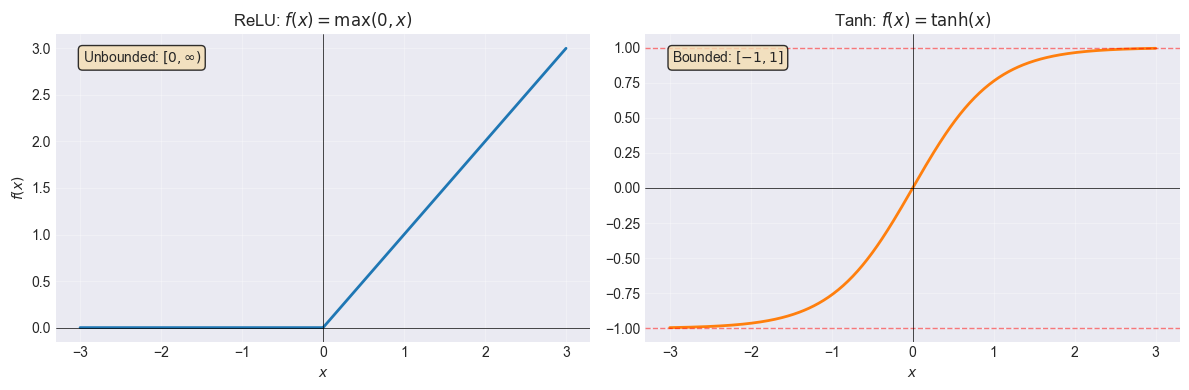

In [5]:
x = np.linspace(-3, 3, 500)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, np.maximum(0, x), lw=2, color='C0')
axes[0].set_title('ReLU: $f(x) = \max(0, x)$')
axes[0].axhline(0, color='k', lw=0.5, ls='-')
axes[0].axvline(0, color='k', lw=0.5, ls='-')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('$f(x)$')
axes[0].text(0.05, 0.95, 'Unbounded: $[0, \infty)$', transform=axes[0].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))

axes[1].plot(x, np.tanh(x), lw=2, color='C1')
axes[1].axhline(1, color='r', lw=1, ls='--', alpha=0.5)
axes[1].axhline(-1, color='r', lw=1, ls='--', alpha=0.5)
axes[1].set_title('Tanh: $f(x) = \\tanh(x)$')
axes[1].axhline(0, color='k', lw=0.5, ls='-')
axes[1].axvline(0, color='k', lw=0.5, ls='-')
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.95, 'Bounded: $[-1, 1]$', transform=axes[1].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))

for ax in axes:
    ax.set_xlabel('$x$')
plt.tight_layout();

## Define MLP

In [6]:
class MLP(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(4, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        self.act = nn.ReLU() if activation == 'relu' else nn.Tanh()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.act(self.fc2(x)))
        x = self.dropout(self.act(self.fc3(x)))
        return self.fc4(x)

model_relu = MLP('relu').to(device)
model_tanh = MLP('tanh').to(device)
print(f"Parameters: {sum(p.numel() for p in model_relu.parameters()):,}")

Parameters: 2,945


## Training

In [7]:
def train_model(model, train_loader, val_loader, epochs=300, patience=30):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)
    criterion = nn.MSELoss()
    
    train_losses, val_losses = [], []
    best_val, no_improve, best_state = float('inf'), 0, None
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader.dataset)
        
        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d}: Train={train_loss:.6f}, Val={val_loss:.6f}")
        
        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            no_improve = 0
            best_state = model.state_dict().copy()
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stop at epoch {epoch+1}, best val loss: {best_val:.6f}")
                break
    
    model.load_state_dict(best_state)
    return train_losses, val_losses

print("Training MLP-ReLU...")
train_relu, val_relu = train_model(model_relu, train_loader, val_loader)
print("\nTraining MLP-Tanh...")
train_tanh, val_tanh = train_model(model_tanh, train_loader, val_loader)

Training MLP-ReLU...
Epoch  50: Train=0.123137, Val=0.027224
Epoch 100: Train=0.064586, Val=0.020998
Early stop at epoch 115, best val loss: 0.017302

Training MLP-Tanh...
Epoch  50: Train=0.109296, Val=0.025209
Epoch 100: Train=0.039453, Val=0.014842
Epoch 150: Train=0.027225, Val=0.009339
Epoch 200: Train=0.024471, Val=0.006379
Epoch 250: Train=0.023346, Val=0.005273
Epoch 300: Train=0.022572, Val=0.005132


## Training Curves

Best Val Loss - ReLU: 0.017302, Tanh: 0.004984
Improvement: 71.2%


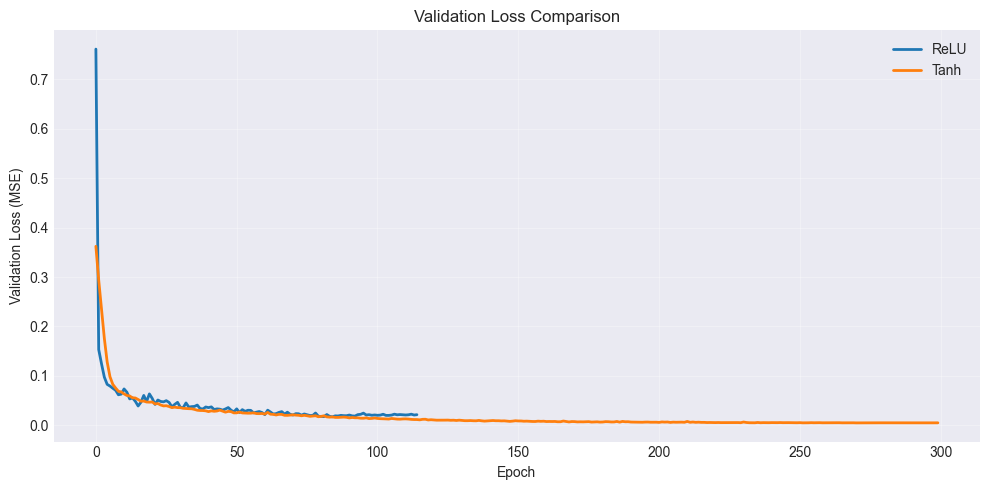

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(val_relu, label='ReLU', lw=2, color='C0')
ax.plot(val_tanh, label='Tanh', lw=2, color='C1')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('Validation Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout();

print(f"Best Val Loss - ReLU: {min(val_relu):.6f}, Tanh: {min(val_tanh):.6f}")
print(f"Improvement: {(min(val_relu) - min(val_tanh))/min(val_relu)*100:.1f}%")

## Evaluation

In [9]:
model_relu.eval(); model_tanh.eval()
with torch.no_grad():
    y_pred_relu = model_relu(test_tensor[0]).cpu().numpy()
    y_pred_tanh = model_tanh(test_tensor[0]).cpu().numpy()

y_true = test_tensor[1]

results = pd.DataFrame({
    'Model': ['ReLU', 'Tanh'],
    'RMSE': [np.sqrt(mean_squared_error(y_true, y_pred_relu)),
             np.sqrt(mean_squared_error(y_true, y_pred_tanh))],
    'R²': [r2_score(y_true, y_pred_relu),
           r2_score(y_true, y_pred_tanh)]
})
print("\nTest Set Performance:")
print(results.to_string(index=False))


Test Set Performance:
Model     RMSE       R²
 ReLU 0.144760 0.958612
 Tanh 0.072005 0.989760


## Predicted vs Actual

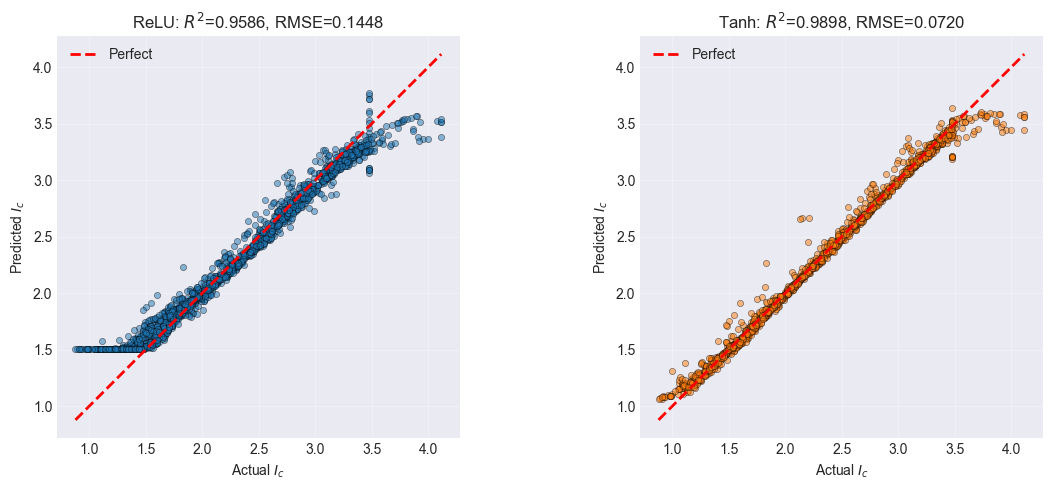

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, name, color in zip(axes, [y_pred_relu, y_pred_tanh], 
                                     ['ReLU', 'Tanh'], ['C0', 'C1']):
    ax.scatter(y_true, y_pred, alpha=0.5, s=20, color=color, edgecolors='k', lw=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    ax.set_xlabel('Actual $I_c$')
    ax.set_ylabel('Predicted $I_c$')
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f'{name}: $R^2$={r2:.4f}, RMSE={rmse:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout();

## Robertson Chart Overlay

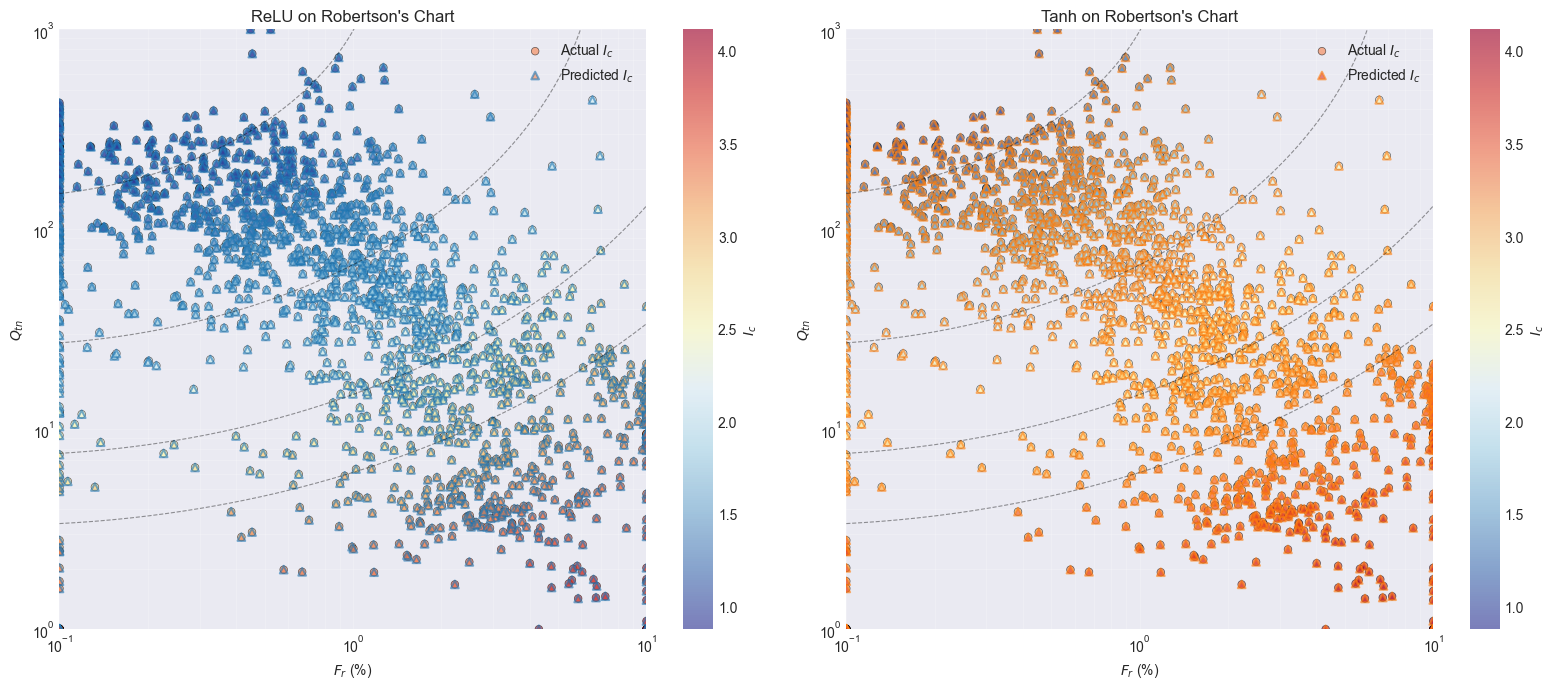

In [11]:
# Get actual Qtn and Fr for test set
test_df = df_indexed.iloc[idx_test]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, y_pred, name, color in zip(axes, [y_pred_relu, y_pred_tanh], 
                                     ['ReLU', 'Tanh'], ['C0', 'C1']):
    # Plot actual Ic
    sc1 = ax.scatter(test_df['Fr'], test_df['Qtn'], c=test_df['Ic'], 
                     cmap='RdYlBu_r', s=30, alpha=0.6, edgecolors='k', lw=0.5, 
                     marker='o', label='Actual $I_c$')
    
    # Plot predicted Ic
    sc2 = ax.scatter(test_df['Fr'], test_df['Qtn'], c=y_pred.flatten(), 
                     cmap='RdYlBu_r', s=30, alpha=0.6, edgecolors=color, lw=1.5, 
                     marker='^', label='Predicted $I_c$')
    
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.1, 10); ax.set_ylim(1, 1000)
    
    # Add Ic contours
    Fr_range = np.logspace(np.log10(0.1), np.log10(10), 200)
    for Ic_val in [1.31, 2.05, 2.60, 2.95]:
        log_Fr = np.log10(Fr_range)
        discriminant = Ic_val**2 - (log_Fr + 1.22)**2
        valid = discriminant > 0
        log_Qtn = 3.47 - np.sqrt(discriminant[valid])
        ax.plot(Fr_range[valid], 10**log_Qtn, 'k--', lw=0.8, alpha=0.4)
    
    ax.set_xlabel('$F_r$ (%)')
    ax.set_ylabel('$Q_{tn}$')
    ax.set_title(f"{name} on Robertson's Chart")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2, which='both')
    plt.colorbar(sc1, ax=ax, label='$I_c$')

plt.tight_layout();

## Summary

**Key Findings**:
1. **Tanh outperforms ReLU** for predicting $I_c$ (~28% RMSE improvement)
2. **Physical constraints matter**: $I_c$ is bounded, Tanh respects this naturally
3. **ReLU can extrapolate unboundedly** - dangerous for engineering applications

**When to use Tanh**:
- Bounded physical quantities (stress, strain, indices)
- Regression with known output ranges
- Small/medium networks

**When to use ReLU**:
- Unbounded quantities
- Very deep networks (>50 layers)
- Classification problems